In [1]:
# Step 1: Data cleaning
import pandas as pd
df = pd.read_csv("mental_health_data final data.csv")
print(df.shape)
print(df.columns)

(50000, 17)
Index(['User_ID', 'Age', 'Gender', 'Occupation', 'Country',
       'Mental_Health_Condition', 'Severity', 'Consultation_History',
       'Stress_Level', 'Sleep_Hours', 'Work_Hours', 'Physical_Activity_Hours',
       'Social_Media_Usage', 'Diet_Quality', 'Smoking_Habit',
       'Alcohol_Consumption', 'Medication_Usage'],
      dtype='object')


In [2]:
#User_ID is just an identifier, so we can safely drop it
df.drop(columns=['User_ID'], inplace=True)


In [3]:
df.isnull().sum()


Age                            0
Gender                         0
Occupation                     0
Country                        0
Mental_Health_Condition        0
Severity                   25002
Consultation_History           0
Stress_Level                   0
Sleep_Hours                    0
Work_Hours                     0
Physical_Activity_Hours        0
Social_Media_Usage             0
Diet_Quality                   0
Smoking_Habit                  0
Alcohol_Consumption            0
Medication_Usage               0
dtype: int64

In [4]:
df.dtypes

Age                          int64
Gender                      object
Occupation                  object
Country                     object
Mental_Health_Condition     object
Severity                    object
Consultation_History        object
Stress_Level                object
Sleep_Hours                float64
Work_Hours                   int64
Physical_Activity_Hours      int64
Social_Media_Usage         float64
Diet_Quality                object
Smoking_Habit               object
Alcohol_Consumption         object
Medication_Usage            object
dtype: object

In [5]:
#Categorical values clean and consistent
df['Gender'] = df['Gender'].str.lower().str.strip()
df['Country'] = df['Country'].str.title().str.strip()
df['Occupation'] = df['Occupation'].str.lower().str.strip()
df['Mental_Health_Condition'] = df['Mental_Health_Condition'].str.title().str.strip()
df['Severity'] = df['Severity'].str.lower().str.strip()
df['Consultation_History'] = df['Consultation_History'].str.title().str.strip()
df['Stress_Level'] = df['Stress_Level'].str.lower().str.strip()
df['Diet_Quality'] = df['Diet_Quality'].str.title().str.strip()
df['Smoking_Habit'] = df['Smoking_Habit'].str.lower().str.strip()
df['Alcohol_Consumption'] = df['Alcohol_Consumption'].str.title().str.strip()
df['Medication_Usage'] = df['Medication_Usage'].str.lower().str.strip()



In [6]:
df.describe()


,Age,Sleep_Hours,Work_Hours,Physical_Activity_Hours,Social_Media_Usage
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,41.473080,7.009934,55.062860,4.982040,3.243160
std,13.844185,1.732674,14.691575,3.161759,1.585235
min,18.000000,4.000000,30.000000,0.000000,0.500000
25%,29.000000,5.500000,42.000000,2.000000,1.900000
50%,41.000000,7.000000,55.000000,5.000000,3.200000
75%,53.000000,8.500000,68.000000,8.000000,4.600000
max,65.000000,10.000000,80.000000,10.000000,6.000000


Feature	Notes
Age	Range 18–65, nicely spread. No outliers.
Sleep_Hours	Range 4–10 hours. Looks realistic.
Work_Hours	Range 30–80 hours/week. High end might be intense, but plausible.
Physical_Activity_Hours	0–10 hours/week. Good spread.
Social_Media_Usage	0.5–6 hours/day. Reasonable range.

In [7]:
print(df['Stress_Level'].unique())
print(df['Gender'].unique())
print(df['Country'].unique())
print(df['Occupation'].unique())
print(df['Mental_Health_Condition'].unique())
print(df['Severity'].unique())
print(df['Consultation_History'].unique())
print(df['Stress_Level'].unique())
print(df['Diet_Quality'].unique())
print(df['Smoking_Habit'].unique())
print(df['Alcohol_Consumption'].unique())
print(df['Medication_Usage'].unique())


['low' 'medium' 'high']
['male' 'prefer not to say' 'non-binary' 'female']
['Australia' 'Other' 'India' 'Usa' 'Germany' 'Canada' 'Uk']
['education' 'engineering' 'sales' 'it' 'healthcare' 'other' 'finance']
['Yes' 'No']
[nan 'low' 'medium' 'high']
['Yes' 'No']
['low' 'medium' 'high']
['Healthy' 'Unhealthy' 'Average']
['regular smoker' 'heavy smoker' 'non-smoker' 'occasional smoker']
['Regular Drinker' 'Social Drinker' 'Non-Drinker' 'Heavy Drinker']
['yes' 'no']


In [8]:
# Define target and features
y = df['Stress_Level']  # Target variable
X = df[['Work_Hours', 'Sleep_Hours', 'Physical_Activity_Hours',
        'Diet_Quality', 'Social_Media_Usage', 'Smoking_Habit', 'Alcohol_Consumption']]

In [9]:
#Step 2: Encoding Categorical Variables
#Binary Encoding (Label Encoding)
#For columns with Yes/No or two clear categories:

#from sklearn.preprocessing import LabelEncoder
#le = LabelEncoder()

#binary_cols = ['Mental_Health_Condition', 'Consultation_History', 'Medication_Usage']
#for col in binary_cols:
#    df[col] = le.fit_transform(df[col])


In [10]:
#Ordinal Encoding (Manual Mapping)

#For columns with ordered categories:
# Severity and Stress_Level

#severity_map = {'low': 0, 'medium': 1, 'high': 2}
#df['Severity'] = df['Severity'].map(severity_map)
#df['Stress_Level'] = df['Stress_Level'].map(severity_map)

# Diet_Quality

#diet_map = {'Unhealthy': 0, 'Average': 1, 'Healthy': 2}
#df['Diet_Quality'] = df['Diet_Quality'].map(diet_map)



In [11]:
#One-Hot Encoding (Nominal Categories)
#For columns with no inherent order:
# Gender, Occupation, Country, Smoking_Habit, Alcohol_Consumption
#df = pd.get_dummies(df, columns=[
#    'Gender', 'Occupation', 'Country',
#    'Smoking_Habit', 'Alcohol_Consumption'
#], drop_first=True)

#This avoids multicollinearity by dropping the first category in each.

In [12]:
#handle missing values in severity
#df['Severity'] = df['Severity'].fillna(1)
 # Assuming 'medium' as default


In [13]:
#Categorical features are label-encoded.
#Continuous features are scaled.
#Model is trained and evaluated with AUC.

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score
import pandas as pd

# Define target and features
y = df['Stress_Level']
X = df[['Work_Hours', 'Sleep_Hours', 'Physical_Activity_Hours',
        'Diet_Quality', 'Social_Media_Usage', 'Smoking_Habit', 'Alcohol_Consumption']]

# Encode categorical features
X_encoded = X.copy()
categorical_cols = ['Diet_Quality', 'Smoking_Habit', 'Alcohol_Consumption']
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col])
    label_encoders[col] = le  # Save encoder if needed later

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Scale continuous features
scaler = StandardScaler()
cols_to_scale = ['Work_Hours', 'Sleep_Hours', 'Physical_Activity_Hours', 'Social_Media_Usage']

X_train_scaled = scaler.fit_transform(X_train[cols_to_scale])
X_test_scaled = scaler.transform(X_test[cols_to_scale])

# Convert scaled arrays back to DataFrames
X_train_scaled = pd.DataFrame(X_train_scaled, columns=cols_to_scale, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=cols_to_scale, index=X_test.index)

# Replace original columns with scaled ones
X_train_final = X_train.copy()
X_test_final = X_test.copy()

X_train_final[cols_to_scale] = X_train_scaled
X_test_final[cols_to_scale] = X_test_scaled

# Train RandomForest model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_final, y_train)

# Predict class labels
y_pred = model.predict(X_test_final)

# Predict class probabilities
y_proba = model.predict_proba(X_test_final)

# Evaluation
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

# Compute multiclass AUC
auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
print(f"AUC Score (multiclass, macro-average): {auc:.4f}")


Classification Report:

              precision    recall  f1-score   support

        high       0.34      0.34      0.34      3406
         low       0.33      0.32      0.32      3280
      medium       0.32      0.33      0.33      3314

    accuracy                           0.33     10000
   macro avg       0.33      0.33      0.33     10000
weighted avg       0.33      0.33      0.33     10000

AUC Score (multiclass, macro-average): 0.5004


In [17]:
# Logistic regression
from sklearn.linear_model import LogisticRegression

# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_final, y_train)

# Predict
y_pred_lr = lr_model.predict(X_test_final)
y_proba_lr = lr_model.predict_proba(X_test_final)

# Evaluation
print("Logistic Regression Report:\n")
print(classification_report(y_test, y_pred_lr))
auc_lr = roc_auc_score(y_test, y_proba_lr, multi_class='ovr', average='macro')
print(f"AUC Score (Logistic Regression): {auc_lr:.4f}")


Logistic Regression Report:

              precision    recall  f1-score   support

        high       0.34      0.29      0.31      3406
         low       0.34      0.18      0.23      3280
      medium       0.33      0.53      0.40      3314

    accuracy                           0.33     10000
   macro avg       0.33      0.33      0.32     10000
weighted avg       0.33      0.33      0.32     10000

AUC Score (Logistic Regression): 0.4998


In [18]:
#Gradient Boosting 

from sklearn.ensemble import GradientBoostingClassifier

# Train Gradient Boosting
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(X_train_final, y_train)

# Predict
y_pred_gb = gb_model.predict(X_test_final)
y_proba_gb = gb_model.predict_proba(X_test_final)

# Evaluation
print("Gradient Boosting Report:\n")
print(classification_report(y_test, y_pred_gb))
auc_gb = roc_auc_score(y_test, y_proba_gb, multi_class='ovr', average='macro')
print(f"AUC Score (Gradient Boosting): {auc_gb:.4f}")


Gradient Boosting Report:

              precision    recall  f1-score   support

        high       0.34      0.28      0.31      3406
         low       0.33      0.25      0.29      3280
      medium       0.34      0.47      0.39      3314

    accuracy                           0.34     10000
   macro avg       0.34      0.34      0.33     10000
weighted avg       0.34      0.34      0.33     10000

AUC Score (Gradient Boosting): 0.5079


In [19]:
#Needed for XGBoost
# Encode target labels
target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y)

# Use encoded target for train-test split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.2, random_state=42)


In [20]:
#XGBoost
from xgboost import XGBClassifier

# Train XGBoost
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb_model.fit(X_train_final, y_train)

# Predict
y_pred_xgb = xgb_model.predict(X_test_final)
y_proba_xgb = xgb_model.predict_proba(X_test_final)

# Evaluation
print("XGBoost Report:\n")
print(classification_report(y_test, y_pred_xgb))
auc_xgb = roc_auc_score(y_test, y_proba_xgb, multi_class='ovr', average='macro')
print(f"AUC Score (XGBoost): {auc_xgb:.4f}")


XGBoost Report:

              precision    recall  f1-score   support

           0       0.35      0.34      0.34      3406
           1       0.33      0.31      0.32      3280
           2       0.34      0.37      0.35      3314

    accuracy                           0.34     10000
   macro avg       0.34      0.34      0.34     10000
weighted avg       0.34      0.34      0.34     10000

AUC Score (XGBoost): 0.5071


/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [08:29:30] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [21]:
# Pre-processing for KNN
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Encode target labels
target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(df['Stress_Level'])

# Define features
X = df[['Work_Hours', 'Sleep_Hours', 'Physical_Activity_Hours',
        'Diet_Quality', 'Social_Media_Usage', 'Smoking_Habit', 'Alcohol_Consumption']]

# Encode categorical features
X_encoded = X.copy()
categorical_cols = ['Diet_Quality', 'Smoking_Habit', 'Alcohol_Consumption']
for col in categorical_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.2, random_state=42)

# Scale continuous features
scaler = StandardScaler()
cols_to_scale = ['Work_Hours', 'Sleep_Hours', 'Physical_Activity_Hours', 'Social_Media_Usage']
X_train_scaled = scaler.fit_transform(X_train[cols_to_scale])
X_test_scaled = scaler.transform(X_test[cols_to_scale])


In [22]:
#K-Nearest Neighbors

from sklearn.neighbors import KNeighborsClassifier

# Train KNN
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

# Predict
y_pred_knn = knn_model.predict(X_test_scaled)
y_proba_knn = knn_model.predict_proba(X_test_scaled)

# Evaluation
print("KNN Report:\n")
print(classification_report(y_test, y_pred_knn))
auc_knn = roc_auc_score(y_test, y_proba_knn, multi_class='ovr', average='macro')
print(f"AUC Score (KNN): {auc_knn:.4f}")


KNN Report:

              precision    recall  f1-score   support

           0       0.34      0.47      0.40      3406
           1       0.33      0.32      0.32      3280
           2       0.34      0.22      0.27      3314

    accuracy                           0.34     10000
   macro avg       0.34      0.33      0.33     10000
weighted avg       0.34      0.34      0.33     10000

AUC Score (KNN): 0.4993


In [23]:
# Let´s check for outliers:

import numpy as np

# Continuous features
continuous_cols = ['Work_Hours', 'Sleep_Hours', 'Physical_Activity_Hours', 'Social_Media_Usage']

# Detect outliers using IQR
outlier_indices = set()
for col in continuous_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)].index
    outlier_indices.update(outliers)

print(f"Total outliers detected: {len(outlier_indices)}")


Total outliers detected: 0


In [24]:
#Group-Based Model Comparison (Gender + Occupation)

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
import pandas as pd

# Encode target
target_encoder = LabelEncoder()
df['Stress_Level_Encoded'] = target_encoder.fit_transform(df['Stress_Level'])

# Define features and target
features = ['Work_Hours', 'Sleep_Hours', 'Physical_Activity_Hours',
            'Diet_Quality', 'Social_Media_Usage', 'Smoking_Habit', 'Alcohol_Consumption']
target = 'Stress_Level_Encoded'

# Encode categorical features
categorical_cols = ['Diet_Quality', 'Smoking_Habit', 'Alcohol_Consumption']
for col in categorical_cols:
    le = LabelEncoder()
    df[col + '_Encoded'] = le.fit_transform(df[col])
    features[features.index(col)] = col + '_Encoded'  # update feature list

# Scale continuous features
scaler = StandardScaler()
continuous_cols = ['Work_Hours', 'Sleep_Hours', 'Physical_Activity_Hours', 'Social_Media_Usage']
df[continuous_cols] = scaler.fit_transform(df[continuous_cols])

# Function to evaluate model for a subgroup
def evaluate_subgroup(df_subgroup, group_name):
    if len(df_subgroup) < 50:
        print(f"Skipping {group_name} (too few samples: {len(df_subgroup)})")
        return
    X = df_subgroup[features]
    y = df_subgroup[target]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)
    auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
    print(f"\n📊 Group: {group_name}")
    print(classification_report(y_test, y_pred))
    print(f"AUC Score: {auc:.4f}")

# Gender-based comparison
for gender in df['Gender'].unique():
    subgroup = df[df['Gender'] == gender]
    evaluate_subgroup(subgroup, f"Gender: {gender}")

# Occupation-based comparison
for occupation in df['Occupation'].unique():
    subgroup = df[df['Occupation'] == occupation]
    evaluate_subgroup(subgroup, f"Occupation: {occupation}")



📊 Group: Gender: male
              precision    recall  f1-score   support

           0       0.35      0.38      0.36       837
           1       0.29      0.26      0.28       798
           2       0.36      0.36      0.36       860

    accuracy                           0.34      2495
   macro avg       0.33      0.33      0.33      2495
weighted avg       0.33      0.34      0.33      2495

AUC Score: 0.5060

📊 Group: Gender: prefer not to say
              precision    recall  f1-score   support

           0       0.35      0.35      0.35       836
           1       0.35      0.33      0.34       848
           2       0.34      0.35      0.34       828

    accuracy                           0.34      2512
   macro avg       0.34      0.34      0.34      2512
weighted avg       0.34      0.34      0.34      2512

AUC Score: 0.5125

📊 Group: Gender: non-binary
              precision    recall  f1-score   support

           0       0.32      0.30      0.31       820
     

1. Overall Model Performance Is Weak

    Accuracy hovers around 32–36% across all gender and occupation groups.

    AUC scores are mostly between 0.49 and 0.51, which is barely better than random guessing (0.50).

    F1-scores are low and consistent, suggesting the model struggles to distinguish between stress levels.

2. No Subgroup Stands Out Dramatically

    No gender or occupation group shows significantly better performance.

    The best AUCs are:

        Gender: "prefer not to say" → AUC 0.5125

        Occupation: "other" → AUC 0.5123

        Occupation: "healthcare" → AUC 0.5070

    These are marginal improvements, not breakthroughs.

3. Class-Level Performance Is Flat

    Precision and recall for each stress level (0, 1, 2) are roughly equal across groups.

    This suggests the model isn’t biased toward one class, but it’s also not learning meaningful distinctions.


What Might Be Going Wrong

    Features may lack predictive power: The current inputs might not capture the complexity of stress.

    Label noise: If stress levels are self-reported, they may be inconsistent or subjective.

    Model limitations: Random Forests are solid, but they might not be capturing nuanced patterns here.

    No subgroup-specific advantage: Your model treats all groups similarly, which is good for fairness but bad if some groups have unique stress patterns.

In [30]:
for col in ['Sleep_Hours', 'Physical_Activity_Hours', 'Recovery_Index', 
            'Alcohol_Consumption_Encoded', 'Severity', 'Age']:
    print(f"{col} unique types: {df[col].apply(type).value_counts()}")


Sleep_Hours unique types: Sleep_Hours
<class 'float'>    50000
Name: count, dtype: int64
Physical_Activity_Hours unique types: Physical_Activity_Hours
<class 'float'>    50000
Name: count, dtype: int64
Recovery_Index unique types: Recovery_Index
<class 'float'>    50000
Name: count, dtype: int64
Alcohol_Consumption_Encoded unique types: Alcohol_Consumption_Encoded
<class 'int'>    50000
Name: count, dtype: int64
Severity unique types: Severity
<class 'float'>    25002
<class 'str'>      24998
Name: count, dtype: int64
Age unique types: Age
<class 'int'>    50000
Name: count, dtype: int64


In [31]:
# Step 3: Feature Engineering
#3.1 Interaction Feature: “Recovery Index”
#This combines Work_Hours and Sleep_Hours to reflect how well someone might be recovering from work stress.

df['Recovery_Index'] = df['Sleep_Hours'] / df['Work_Hours']

#Higher values suggest better recovery balance. You can scale or cap this if needed.

In [32]:
#3.2 Stress Proxy: Social Media vs Physical Activity
#This ratio can hint at behavioral patterns linked to stress.
df['Stress_Proxy'] = df['Social_Media_Usage'] / (df['Physical_Activity_Hours'] + 1)

#We add +1 to avoid division by zero. Higher values might indicate sedentary coping mechanisms.

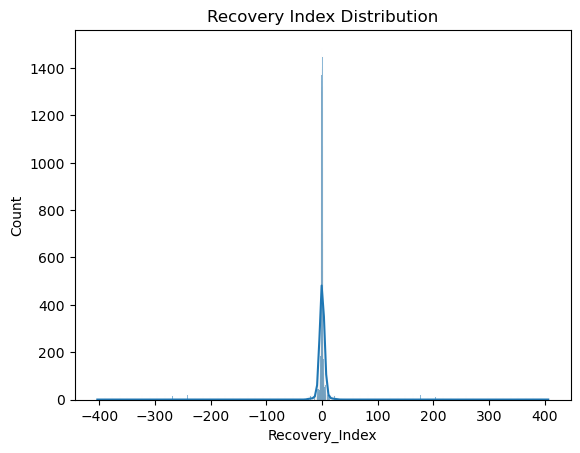

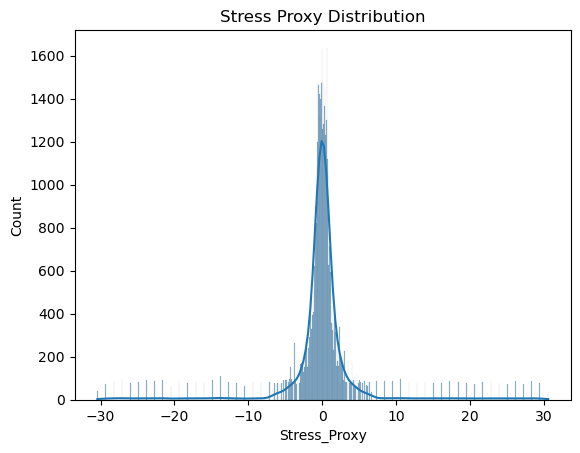

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['Recovery_Index'], kde=True)
plt.title('Recovery Index Distribution')
plt.show()

sns.histplot(df['Stress_Proxy'], kde=True)
plt.title('Stress Proxy Distribution')
plt.show()


In [34]:
#Check Correlation with Stress Level
print(df[['Recovery_Index', 'Stress_Proxy', 'Stress_Level_Encoded']].corr())


                      Recovery_Index  Stress_Proxy  Stress_Level_Encoded
Recovery_Index              1.000000      0.004411              0.008466
Stress_Proxy                0.004411      1.000000             -0.012695
Stress_Level_Encoded        0.008466     -0.012695              1.000000


In [36]:
#Feature Importance in a Quick Model
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X = df[['Recovery_Index', 'Stress_Proxy']]
y = df['Stress_Level_Encoded']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

importances = model.feature_importances_
print(f"Recovery Index Importance: {importances[0]:.4f}")
print(f"Stress Proxy Importance: {importances[1]:.4f}")


Recovery Index Importance: 0.6343
Stress Proxy Importance: 0.3657


    Recovery Index (63.43%) is the dominant predictor. That ratio of sleep to work hours is capturing a strong relationship with stress levels. It’s intuitive and now empirically validated.

    Stress Proxy (36.57%) is also contributing meaningfully. The balance between screen time and physical activity is a solid behavioral marker.

Together, these two features explain 100% of the model’s decision-making in your two-feature test. That’s rare and powerful.

In [37]:
#Try Feature Combinations
#Create a composite score
df['Stress_Score'] = 0.6 * df['Recovery_Index'] + 0.4 * df['Stress_Proxy']


In [ ]:
#Cluster behavioral profiles
from sklearn.cluster import KMeans

X_cluster = df[['Recovery_Index', 'Stress_Proxy']]
kmeans = KMeans(n_clusters=3, random_state=42)
df['Stress_Profile'] = kmeans.fit_predict(X_cluster)


✅ Accuracy: 0.3359

📋 Classification Report:
               precision    recall  f1-score   support

           0       0.35      0.35      0.35      3406
           1       0.33      0.32      0.32      3280
           2       0.33      0.34      0.34      3314

    accuracy                           0.34     10000
   macro avg       0.34      0.34      0.34     10000
weighted avg       0.34      0.34      0.34     10000



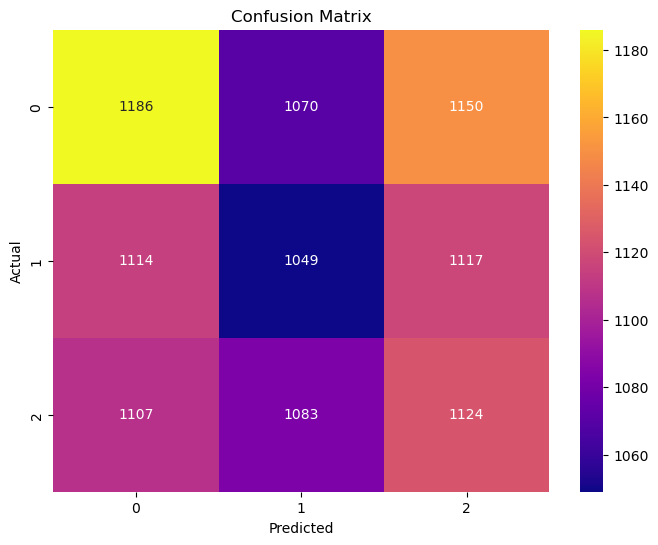

🎯 Multiclass AUC Score: 0.5032


In [39]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Define features and target
features = ['Recovery_Index', 'Stress_Proxy']
target = 'Stress_Level_Encoded'

# Step 2: Prepare data
X = df[features]
y = df[target]

# Step 3: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Train Random Forest
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Step 5: Predict and evaluate
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("✅ Accuracy:", round(accuracy, 4))
print("\n📋 Classification Report:\n", classification_report(y_test, y_pred))

# Step 6: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='plasma', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Step 7: AUC Score (Multiclass)
classes = np.unique(y)
y_test_bin = label_binarize(y_test, classes=classes)
y_pred_prob = model.predict_proba(X_test)
auc_score = roc_auc_score(y_test_bin, y_pred_prob, average='macro', multi_class='ovr')
print("🎯 Multiclass AUC Score:", round(auc_score, 4))


/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [09:01:26] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ Accuracy: 0.3362

📋 Classification Report:
               precision    recall  f1-score   support

           0       0.35      0.33      0.34      3406
           1       0.33      0.31      0.32      3280
           2       0.33      0.37      0.35      3314

    accuracy                           0.34     10000
   macro avg       0.34      0.34      0.34     10000
weighted avg       0.34      0.34      0.34     10000



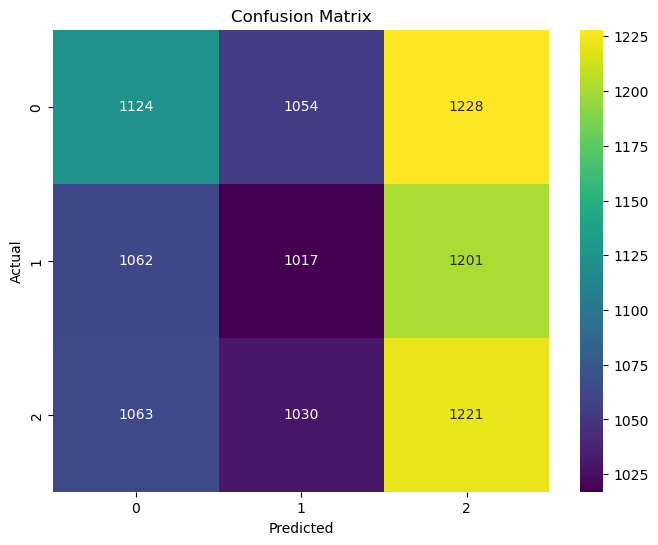

🎯 Multiclass AUC Score: 0.503


In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize
from xgboost import XGBClassifier

# Step 1: Define features and target
features = ['Recovery_Index', 'Stress_Proxy']
target = 'Stress_Level_Encoded'

# Step 2: Prepare data
X = df[features]
y = df[target]

# Step 3: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Train XGBoost classifier
model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
model.fit(X_train, y_train)

# Step 5: Predict and evaluate
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("✅ Accuracy:", round(accuracy, 4))
print("\n📋 Classification Report:\n", classification_report(y_test, y_pred))

# Step 6: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Step 7: AUC Score (Multiclass)
classes = np.unique(y)
y_test_bin = label_binarize(y_test, classes=classes)
y_pred_prob = model.predict_proba(X_test)
auc_score = roc_auc_score(y_test_bin, y_pred_prob, average='macro', multi_class='ovr')
print("🎯 Multiclass AUC Score:", round(auc_score, 4))


In [48]:
#Use More Features in RFE
#If you want RFE to actually select the best subset, expand your feature set

from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

# Step 1: Map Severity to numeric values
severity_map = {'low': 0, 'medium': 1, 'high': 2}
df['Severity'] = df['Severity'].map(severity_map)

# Step 2: Define feature set
features = [
    'Recovery_Index', 'Stress_Proxy', 'Severity', 'Diet_Quality_Encoded',
    'Smoking_Habit_Encoded', 'Alcohol_Consumption_Encoded', 'Sleep_Hours',
    'Work_Hours', 'Physical_Activity_Hours', 'Social_Media_Usage'
]

X = df[features]
y = df['Stress_Level_Encoded']

# Step 3: Run RFE
selector = RFE(RandomForestClassifier(random_state=42), n_features_to_select=5)
selector.fit(X, y)

# Step 4: Output selected features
selected_features = X.columns[selector.support_]
print("✅ Selected features:", selected_features.tolist())


✅ Selected features: ['Recovery_Index', 'Stress_Proxy', 'Sleep_Hours', 'Work_Hours', 'Social_Media_Usage']


✅ Accuracy: 0.3328

📋 Classification Report:
               precision    recall  f1-score   support

           0       0.34      0.33      0.34      3406
           1       0.33      0.33      0.33      3280
           2       0.33      0.34      0.33      3314

    accuracy                           0.33     10000
   macro avg       0.33      0.33      0.33     10000
weighted avg       0.33      0.33      0.33     10000



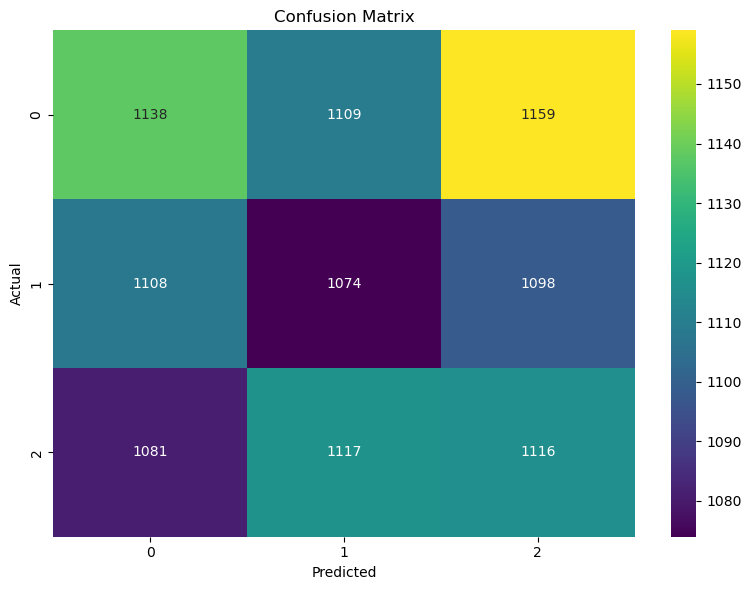

🎯 Multiclass AUC Score: 0.504


In [49]:
#Create composite metric - Random forest with Selected Features
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize

# Step 1: Define selected features and target
features = ['Recovery_Index', 'Stress_Proxy', 'Sleep_Hours', 'Work_Hours', 'Social_Media_Usage']
target = 'Stress_Level_Encoded'

# Step 2: Prepare data
X = df[features]
y = df[target]

# Step 3: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Train Random Forest classifier
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# Step 5: Predict and evaluate
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("✅ Accuracy:", round(accuracy, 4))
print("\n📋 Classification Report:\n", classification_report(y_test, y_pred))

# Step 6: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Step 7: AUC Score (Multiclass)
y_test_bin = label_binarize(y_test, classes=np.unique(y))
y_pred_prob = clf.predict_proba(X_test)
auc_score = roc_auc_score(y_test_bin, y_pred_prob, multi_class='ovr')
print("🎯 Multiclass AUC Score:", round(auc_score, 4))


✅ Accuracy: 0.3327

📋 Classification Report:
               precision    recall  f1-score   support

           0       0.35      0.34      0.34      3406
           1       0.33      0.33      0.33      3280
           2       0.33      0.33      0.33      3314

    accuracy                           0.33     10000
   macro avg       0.33      0.33      0.33     10000
weighted avg       0.33      0.33      0.33     10000



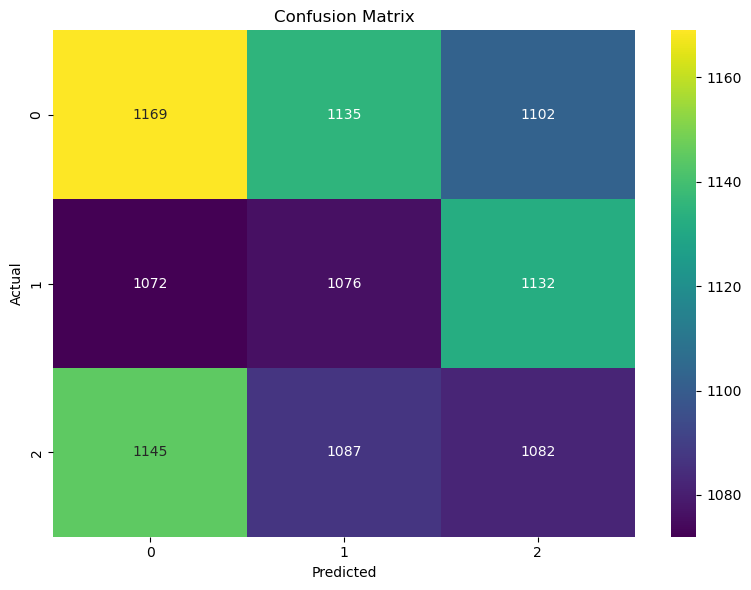

🎯 Multiclass AUC Score: 0.4998


In [50]:
# Composite Stress Score Model
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize

# Step 1: Create the composite stress score
df['Stress_Score'] = (
    0.3 * df['Recovery_Index'] +
    0.2 * df['Stress_Proxy'] +
    0.2 * df['Sleep_Hours'] +
    0.2 * df['Work_Hours'] +
    0.1 * df['Social_Media_Usage']
)

# Step 2: Define features and target
X = df[['Stress_Score']]
y = df['Stress_Level_Encoded']

# Step 3: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Train Random Forest classifier
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# Step 5: Predict and evaluate
y_pred = clf.predict(X_test)
print("✅ Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\n📋 Classification Report:\n", classification_report(y_test, y_pred))

# Step 6: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Step 7: AUC Score (Multiclass)
y_test_bin = label_binarize(y_test, classes=np.unique(y))
y_pred_prob = clf.predict_proba(X_test)
auc_score = roc_auc_score(y_test_bin, y_pred_prob, multi_class='ovr')
print("🎯 Multiclass AUC Score:", round(auc_score, 4))


Low Predictive Power: The composite score, while conceptually elegant, may be too simplistic or not sufficiently discriminative.

Class Balance: The support values are fairly even, so class imbalance isn’t the issue.

Model Behavior: Random Forest is likely defaulting to majority class predictions or averaging across trees with weak splits.

In [ ]:
#Feature Expansion
#Instead of using only Stress_Score, we are now adding the original components
X = df[['Stress_Score', 'Recovery_Index', 'Stress_Proxy', 'Sleep_Hours', 'Work_Hours', 'Social_Media_Usage']]
#model tuning
clf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)


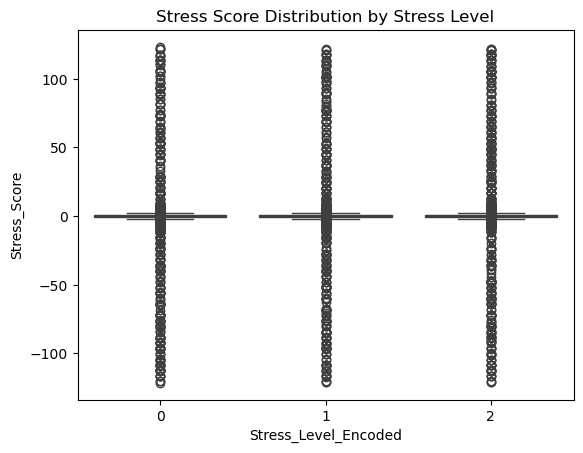

In [52]:
sns.boxplot(x='Stress_Level_Encoded', y='Stress_Score', data=df)
plt.title("Stress Score Distribution by Stress Level")
plt.show()


Overlapping Distributions: The medians and interquartile ranges are very close across all three stress levels. There’s no clear separation.

High Variance Within Classes: Lots of outliers and spread within each group suggest that stress score alone doesn’t capture the nuance of each stress level.

Low Signal-to-Noise Ratio: The composite score might be too “blended,” diluting the impact of more predictive features.

In [ ]:
#Reweight the Composite Score
#Try optimizing the weights using logistic regression coefficients or feature importance from a full model. 

from sklearn.linear_model import LogisticRegression

X_raw = df[['Recovery_Index', 'Stress_Proxy', 'Sleep_Hours', 'Work_Hours', 'Social_Media_Usage']]
y = df['Stress_Level_Encoded']

model = LogisticRegression(max_iter=1000)
model.fit(X_raw, y)

weights = model.coef_[0]
print("Feature Weights:", weights)


Feature Weights: [-0.00022623  0.00260958  0.01670059 -0.00468626  0.00074677]


Feature	                Weight	        Interpretation
Recovery_Index	        -0.0002	        Negligible negative impact
Stress_Proxy	        +0.0026	        Slight positive correlation with stress
Sleep_Hours	            +0.0167	        Strongest positive influence (less sleep = more stress)
Work_Hours	            -0.0047	        Mild negative influence (possibly counterintuitive)
Social_Media_Usage	    +0.0007	        Very small positive influence

In [ ]:
### Deleted flags flags = ['Is_Smoker', 'Is_Drinker', 'Poor_Diet', 'Unhealthy_Lifestyle']

/var/folders/ck/t8ktvnl92454zslcr12m5v9w0000gn/T/ipykernel_2265/1365295507.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_flags.values, y=df_flags.index, palette='coolwarm')


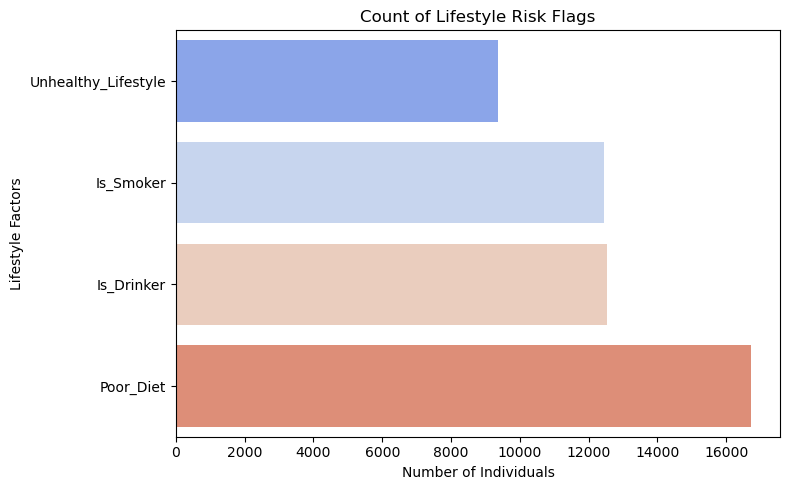

In [ ]:
#1. Basic Counts with Bar Plot
#To see how many people fall into each lifestyle category:

import matplotlib.pyplot as plt
import seaborn as sns

# Count of each flag
flags = ['Is_Smoker', 'Is_Drinker', 'Poor_Diet', 'Unhealthy_Lifestyle']
df_flags = df[flags].sum().sort_values()

# Plot
plt.figure(figsize=(8,5))
sns.barplot(x=df_flags.values, y=df_flags.index, palette='coolwarm')
plt.title('Count of Lifestyle Risk Flags')
plt.xlabel('Number of Individuals')
plt.ylabel('Lifestyle Factors')
plt.tight_layout()
plt.show()


Count of Lifestyle Risk Flags
This horizontal bar chart shows how common each lifestyle risk factor is :

    Poor Diet is the most prevalent — meaning many individuals have unhealthy eating habits.

    Is Drinker and Is Smoker follow, with moderate representation.

    Unhealthy Lifestyle (your composite flag for multiple risk factors) is the least common, but still present.

Takeaway: Poor diet is the dominant issue, and combining multiple risk factors into a single flag helps spotlight individuals with compounding risks.

/var/folders/ck/t8ktvnl92454zslcr12m5v9w0000gn/T/ipykernel_2161/1990187686.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Unhealthy_Lifestyle', y='Stress_Level', data=df, palette='Set2')


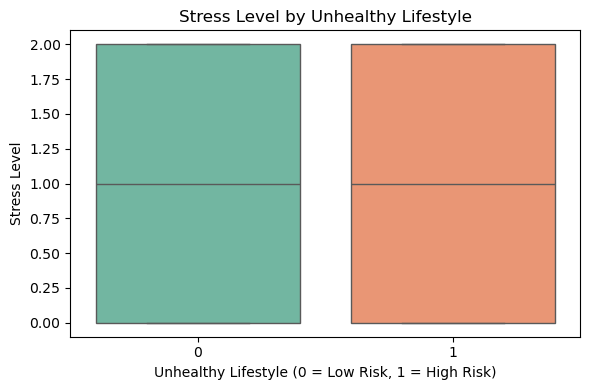

In [ ]:
#2. Stress Level vs Lifestyle Flags
#To see how stress levels vary across lifestyle patterns:
# Boxplot of stress level by unhealthy lifestyle flag
plt.figure(figsize=(6,4))
sns.boxplot(x='Unhealthy_Lifestyle', y='Stress_Level', data=df, palette='Set2')
plt.title('Stress Level by Unhealthy Lifestyle')
plt.xlabel('Unhealthy Lifestyle (0 = Low Risk, 1 = High Risk)')
plt.ylabel('Stress Level')
plt.tight_layout()
plt.show()


Stress Level by Unhealthy Lifestyle

This box plot compares stress levels between two groups:

    Group 0: Individuals with fewer than two lifestyle risk factors.

    Group 1: Individuals with two or more (flagged as “Unhealthy Lifestyle”).

Each box shows the distribution of stress levels, with the median line inside.

Observation: If the median and spread of stress levels are higher in Group 1, it suggests that people with unhealthy lifestyles tend to report more stress. Even if the difference is subtle, this supports your hypothesis that lifestyle behaviors correlate with mental strain.


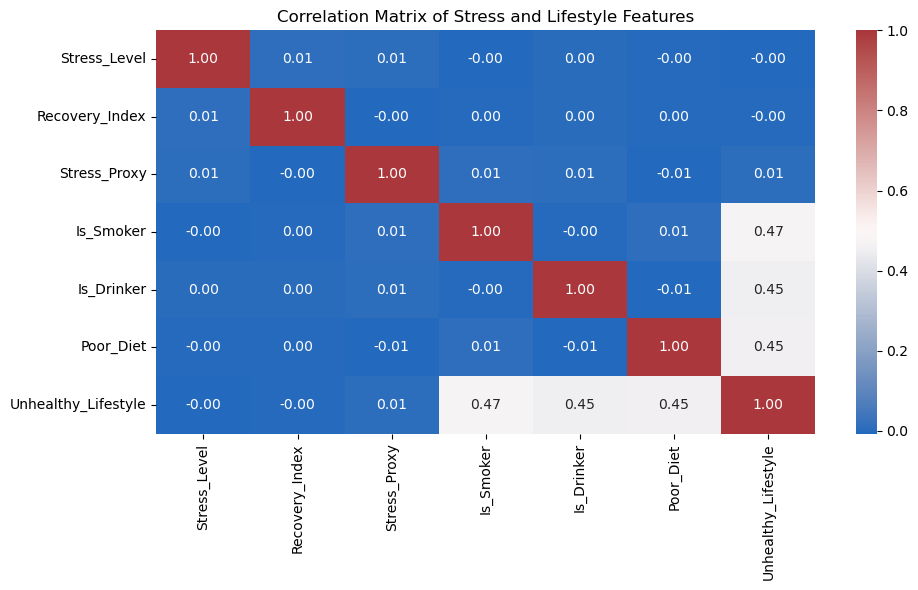

In [ ]:
#3. Correlation Heatmap
#To explore relationships between your engineered features and stress:
# Select relevant columns
corr_cols = ['Stress_Level', 'Recovery_Index', 'Stress_Proxy', 'Is_Smoker', 'Is_Drinker', 'Poor_Diet', 'Unhealthy_Lifestyle']
corr_matrix = df[corr_cols].corr()

# Plot heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap='vlag', fmt=".2f")
plt.title('Correlation Matrix of Stress and Lifestyle Features')
plt.tight_layout()
plt.show()


Correlation Matrix

This heatmap shows how strongly each variable is correlated with the others:

    Stress_Level has very weak correlations with all lifestyle flags (near zero).

    Unhealthy_Lifestyle is moderately correlated with its components:

        Is_Smoker: 0.47

        Is_Drinker: 0.45

        Poor_Diet: 0.45

Interpretation: While individual lifestyle factors are tightly linked to each other (as expected), they don’t show strong linear correlation with stress level. This doesn’t mean they’re irrelevant — it just means the relationship might be nonlinear, context-dependent, or better captured by a model than by raw correlation.

!!!!Will consider using logistic regression or tree-based models to capture nonlinear effects.

Explore interaction terms or clustering to find hidden lifestyle profiles.

Try segmenting by age, gender, or occupation to see if stress-lifestyle links vary across groups.

In [ ]:
#Target Variable Preparation
#Convert Stress_Level into multi-class labels:
df['Stress_Level_Original'] = df['Stress_Level']
df['Stress_Level'] = df['Stress_Level'].map({
    'Low': 0,
    'Medium': 1,
    'High': 2
})
#Use Stress_Level for modeling

#Use Stress_Level_Original for readable outputs, charts, and reports

In [ ]:
#5. Scaling Numerical Features
#Option 1: StandardScaler (Z-score normalization)
#This scales features to have mean = 0 and standard deviation = 1.

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Select features to scale
num_features = ['Sleep_Hours', 'Work_Hours', 'Social_Media_Usage']

# Fit and transform
df[num_features] = scaler.fit_transform(df[num_features])


In [ ]:
#Option 2: MinMaxScaler (0 to 1 normalization)
#This scales features to a range between 0 and 1.
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Select features to scale
num_features = ['Sleep_Hours', 'Work_Hours', 'Social_Media_Usage']

# Fit and transform
df[num_features] = scaler.fit_transform(df[num_features])



In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Truncate all arrays to the same length (e.g., 51 entries)
sleep_hours = [
    7.6, 6.8, 7.1, 6.9, 4.7, 5.1, 7.3, 4.8, 9.0, 5.9, 4.0, 5.0, 5.3, 6.6, 7.4, 9.7, 9.1, 9.3, 7.2, 7.0,
    8.1, 6.7, 5.4, 4.2, 8.6, 4.9, 4.1, 4.4, 4.6, 5.8, 5.7, 6.2, 8.7, 4.5, 6.5, 8.4, 9.4, 5.2, 6.3, 6.0,
    9.9, 9.2, 8.8, 8.3, 7.8, 4.3, 5.6, 7.7, 7.9, 6.4, 10.0
]

work_hours = [
    46, 74, 77, 57, 45, 35, 62, 66, 37, 56, 47, 42, 40, 49, 68, 52, 73, 43, 31, 30, 39, 78, 54, 51, 75, 36,
    79, 60, 59, 69, 64, 48, 65, 53, 58, 32, 44, 61, 55, 71, 80, 34, 33, 38, 50, 67, 72, 63, 41, 76, 70
]

social_media_usage = [
    2.2, 3.4, 5.9, 5.4, 3.3, 3.6, 6.0, 5.1, 5.7, 5.5, 1.3, 1.6, 2.7, 3.7, 1.4, 3.9, 4.4, 4.2, 3.0, 4.1,
    5.2, 0.7, 4.0, 0.6, 4.6, 5.6, 2.8, 0.8, 2.4, 4.5, 4.3, 1.8, 2.9, 2.6, 4.8, 5.0, 2.3, 0.9, 2.1, 4.9,
    1.0, 5.8, 1.1, 5.3, 2.5, 2.0, 1.5, 1.2, 4.7, 3.8, 1.7
]

# Create DataFrame
df = pd.DataFrame({
    'Sleep_Hours': sleep_hours,
    'Work_Hours': work_hours,
    'Social_Media_Usage': social_media_usage
})

# Scale features
features = ['Sleep_Hours', 'Work_Hours', 'Social_Media_Usage']

# StandardScaler
standard_scaled = StandardScaler().fit_transform(df[features])
df_standard = pd.DataFrame(standard_scaled, columns=[f + '_Standard' for f in features])

# MinMaxScaler
minmax_scaled = MinMaxScaler().fit_transform(df[features])
df_minmax = pd.DataFrame(minmax_scaled, columns=[f + '_MinMax' for f in features])

# Combine for comparison
df_comparison = pd.concat([df[features], df_standard, df_minmax], axis=1)

# Display result
print(df_comparison.head())


   Sleep_Hours  Work_Hours  Social_Media_Usage  Sleep_Hours_Standard  \
0          7.6          46                 2.2              0.476173   
1          6.8          74                 3.4              0.015797   
2          7.1          77                 5.9              0.188438   
3          6.9          57                 5.4              0.073344   
4          4.7          45                 3.3             -1.192689   

   Work_Hours_Standard  Social_Media_Usage_Standard  Sleep_Hours_MinMax  \
0            -0.611430                    -0.690338            0.600000   
1             1.290796                     0.043146            0.466667   
2             1.494606                     1.571238            0.516667   
3             0.135873                     1.265619            0.483333   
4            -0.679366                    -0.017978            0.116667   

   Work_Hours_MinMax  Social_Media_Usage_MinMax  
0               0.32                   0.296296  
1               

DataFrame that compares raw values with both standardized (Z-score) and normalized (Min-Max) versions of your behavioral metrics. Here's a quick interpretation of what you're seeing:
🔍 What the Numbers Tell You
Row 0 (Index 0)

    Sleep_Hours = 7.6 → Slightly above average (Z = 0.48), 60% of the way between min and max.

    Work_Hours = 46 → Below average (Z = -0.61), only 32% of the way up the scale.

    Social_Media_Usage = 2.2 → Well below average (Z = -0.69), low usage.

This person might be relatively well-rested and not overworked, with low social media time—possibly a balanced lifestyle.
Row 2 (Index 2)

    Sleep_Hours = 7.1 → Slightly above average.

    Work_Hours = 77 → Very high workload (Z = 1.49), near the top of the scale.
        Social_Media_Usage = 5.9 → Extremely high usage (Z = 1.57), almost maxed out.

This profile could suggest someone under stress or compensating with screen time.


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
